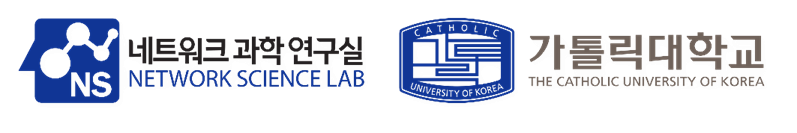

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W11/Sample_Code_11.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 1. LINE: Large-scale Information Network Embedding

LINE (Large-scale Information Network Embedding) is a robust method for network representation learning. It optimizes an objective function designed to preserve both **first-order** (local) and **second-order** (global) proximities.

In this notebook, we explore the core building blocks for large graph embedding models:
1. **Alias Sampling:** Efficient $O(1)$ sampling of edges.
2. **Matrix Decomposition (SVD):** Decomposing the Katz Index similarity matrix to extract low-dimensional embeddings.

In [1]:
!pip install Vose-Alias-Method

In [2]:
# Import library
import networkx as nx
import numpy as np
from vose_sampler import VoseAlias
import matplotlib.pyplot as plt
import collections
from tqdm import tqdm
from tqdm import trange

In [3]:
# Load the karate club network
G = nx.karate_club_graph()

# Define the first-order proximity matrix
P = nx.to_numpy_array(G)

# Normalize the proximity matrix
P_normalized = P / P.sum(axis=1)[:, np.newaxis]

print(P_normalized)

[[0.         0.0952381  0.11904762 ... 0.04761905 0.         0.        ]
 [0.13793103 0.         0.20689655 ... 0.         0.         0.        ]
 [0.15151515 0.18181818 0.         ... 0.         0.06060606 0.        ]
 ...
 [0.0952381  0.         0.         ... 0.         0.19047619 0.19047619]
 [0.         0.         0.05263158 ... 0.10526316 0.         0.13157895]
 [0.         0.         0.         ... 0.08333333 0.10416667 0.        ]]


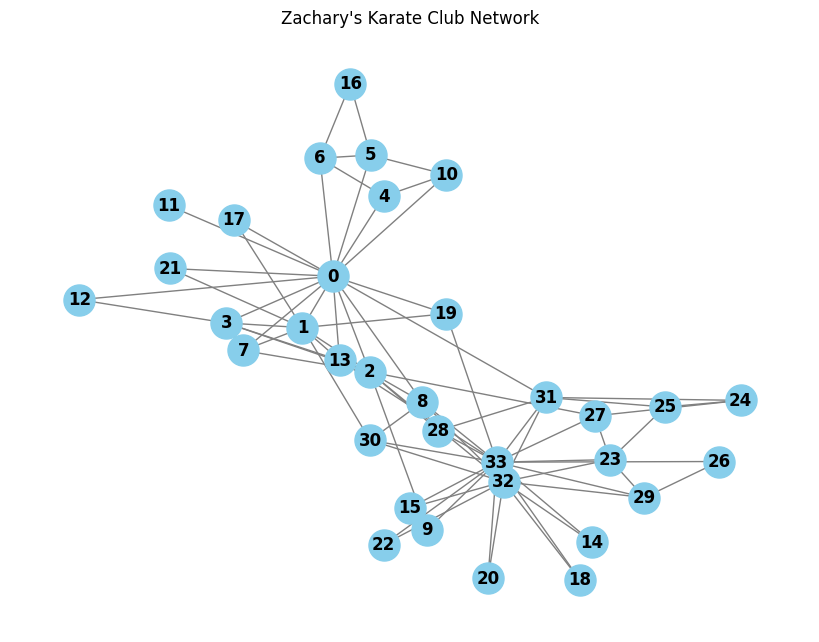

In [6]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) # For a consistent layout
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_weight='bold')
plt.title("Zachary's Karate Club Network")
plt.show()

## 1.1. Edge Sampling using Vose's Alias Method

In large graphs, sampling edges repeatedly based on their weights can be extremely slow if done naively $O(n)$. **Alias Sampling** (specifically Vose's Alias Method) is an algorithm that allows us to sample from a discrete probability distribution in **$O(1)$ time**, after an $O(n)$ preprocessing step.

Here, we'll manually implement the preprocessing (`create_alias_table`) and sampling (`alias_sample`), then simulate its output against the expected ground truth probabilities.

In [7]:
def create_alias_table(area_ratio):
    l = len(area_ratio)
    accept, alias = [0] * l, [0] * l
    small, large = [], []
    area_ratio_ = np.array(area_ratio) * l
    for i, prob in enumerate(area_ratio_):
        if prob < 1.0:
            small.append(i)
        else:
            large.append(i)

    while small and large:
        small_idx, large_idx = small.pop(), large.pop()
        accept[small_idx] = area_ratio_[small_idx]
        alias[small_idx] = large_idx
        area_ratio_[large_idx] = area_ratio_[large_idx] - \
                                 (1 - area_ratio_[small_idx])
        if area_ratio_[large_idx] < 1.0:
            small.append(large_idx)
        else:
            large.append(large_idx)

    while large:
        large_idx = large.pop()
        accept[large_idx] = 1
    while small:
        small_idx = small.pop()
        accept[small_idx] = 1

    return accept, alias


def alias_sample(accept, alias):
    N = len(accept)
    i = int(np.random.random() * N)
    r = np.random.random()
    if r < accept[i]:
        return i
    else:
        return alias[i]

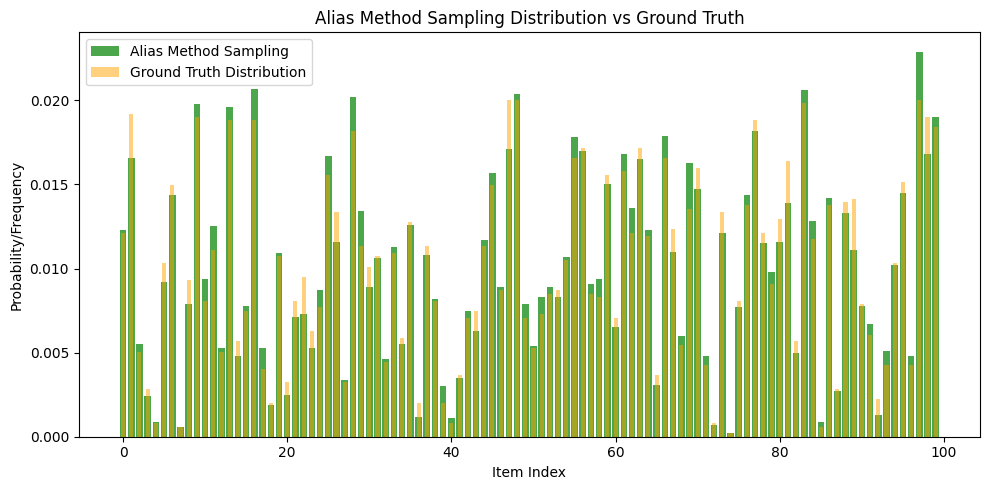

In [8]:
def gen_prob_dist(N):
    p = np.random.randint(0, 100, N)
    return p / np.sum(p)

def simulate(N=100, k=10000):
    truth = gen_prob_dist(N)
    area_ratio = truth
    accept, alias = create_alias_table(area_ratio)

    ans = np.zeros(N)
    for _ in range(k):
        i = alias_sample(accept, alias)
        ans[i] += 1
    return ans / np.sum(ans), truth


alias_result, truth = simulate()

plt.figure(figsize=(10, 5))
x_indices = list(range(len(alias_result)))
plt.bar(x_indices, alias_result, label='Alias Method Sampling', alpha=0.7, color='green')
plt.bar(x_indices, truth, label='Ground Truth Distribution', alpha=0.5, color='orange', width=0.5)

plt.title("Alias Method Sampling Distribution vs Ground Truth")
plt.xlabel("Item Index")
plt.ylabel("Probability/Frequency")
plt.legend()
plt.tight_layout()
plt.show()

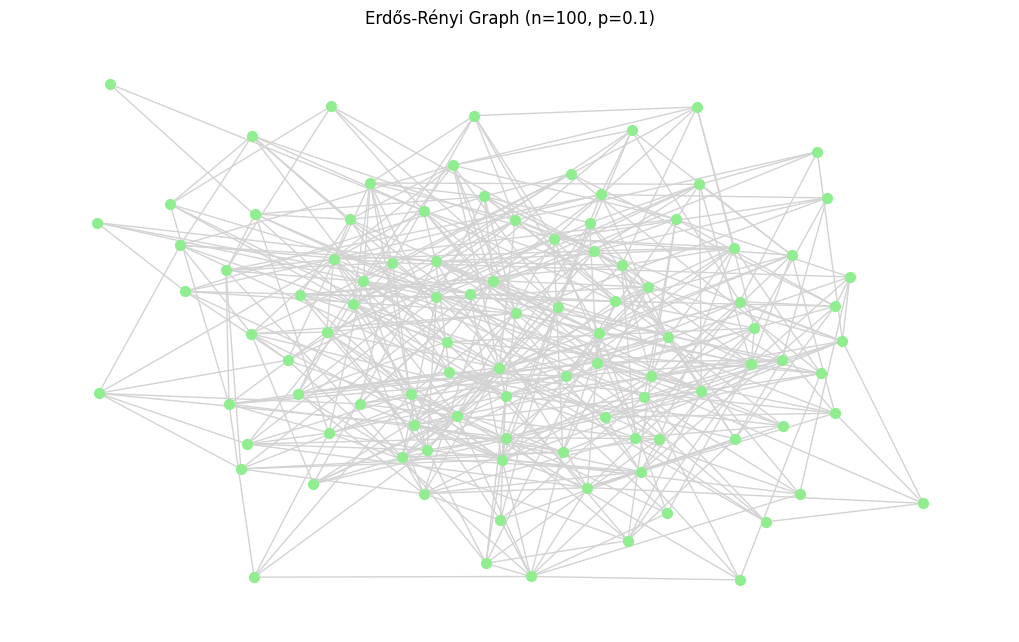

Total edges processed: 475
Sample normalized edge (edge, probability): ((0, 3), 0.003102155508110235)


In [9]:
# Create an Erdős-Rényi graph with 100 nodes and probability 0.1
G_erdos = nx.erdos_renyi_graph(100, 0.1)

# Plot the graph with basic layout
plt.figure(figsize=(10, 6))
pos_erdos = nx.spring_layout(G_erdos, seed=42)
nx.draw(G_erdos, pos_erdos, node_size=50, node_color='lightgreen', edge_color='lightgray', with_labels=False)
plt.title("Erdős-Rényi Graph (n=100, p=0.1)")
plt.show()

# Get the edge list of the graph
edge_list = G_erdos.edges

# Create a dictionary to store the edge list with weights
edgedistdict = collections.defaultdict(float)
weightsum = 0.0

# Assign random weights
for edge in edge_list:
    weight = np.random.uniform(1, 100)
    edgedistdict[(edge[0], edge[1])] = weight
    weightsum += weight

# Normalize weights so they represent probabilities
for edge, weight in edgedistdict.items():
    edgedistdict[edge] = weight / weightsum

print(f"Total edges processed: {len(edgedistdict)}")
print(f"Sample normalized edge (edge, probability): {list(edgedistdict.items())[0]}")

In [10]:
# Edge sampling using alias table
edgesaliassampler = VoseAlias(edgedistdict)
batchrange = int(len(edgedistdict) / 5)

for b in trange(batchrange):
  print(edgesaliassampler.sample_n(size=5))

100%|██████████| 95/95 [00:00<00:00, 91326.81it/s]

[(23, 82), (1, 7), (76, 89), (20, 39), (17, 89)]
[(48, 84), (10, 13), (45, 54), (33, 48), (41, 52)]
[(23, 82), (76, 84), (38, 96), (3, 76), (17, 33)]
[(79, 96), (62, 72), (61, 67), (19, 74), (51, 70)]
[(50, 94), (0, 73), (7, 97), (7, 66), (47, 63)]
[(4, 5), (37, 58), (12, 38), (20, 39), (17, 91)]
[(33, 44), (96, 99), (18, 30), (89, 99), (0, 52)]
[(33, 71), (26, 61), (59, 91), (7, 70), (63, 77)]
[(33, 44), (61, 66), (31, 45), (29, 68), (5, 33)]
[(14, 45), (75, 99), (41, 59), (43, 88), (18, 22)]
[(20, 28), (64, 72), (31, 48), (33, 48), (52, 90)]
[(19, 24), (2, 47), (2, 7), (26, 87), (67, 81)]
[(1, 72), (59, 90), (8, 61), (3, 60), (12, 38)]
[(57, 83), (24, 92), (35, 48), (2, 7), (3, 17)]
[(54, 79), (61, 66), (87, 88), (4, 80), (76, 90)]
[(33, 66), (19, 66), (12, 38), (28, 48), (33, 48)]
[(28, 32), (22, 75), (1, 7), (6, 72), (9, 11)]
[(3, 55), (14, 99), (5, 49), (0, 52), (28, 82)]
[(4, 80), (67, 81), (3, 60), (75, 84), (41, 59)]
[(81, 84), (12, 38), (33, 54), (5, 66), (17, 46)]
[(22, 99), 

# 2. Singular Value Decomposition in Matrix Adjacency

The **Katz Index** computes the relative influence of a node within a network by measuring the number of all walks between a pair of nodes, penalizing longer walks. 

Here, we decompose the similarity matrix generated by the Katz Index using **Singular Value Decomposition (SVD)** to extract low-dimensional node embeddings. This structural decomposition gives us node representations mathematically grounded in the global structure of the network.

In [11]:
import networkx as nx
import numpy as np
from scipy.sparse.linalg import svds

# Load the karate club network (re-loading for self-containment)
G = nx.karate_club_graph()

# Define the Katz index similarity
def katz_index(G, alpha=0.5, max_iter=100, tol=1e-3):
    n = len(G.nodes())
    A = nx.adjacency_matrix(G).todense()
    I = np.eye(n)
    X = I
    converged = False
    for i in range(max_iter):
        X_prev = X
        X = alpha * A.dot(X) + (1 - alpha) * I
        if np.linalg.norm(X - X_prev) < tol:
            converged = True
            break
    return X

# Compute the Katz index similarity matrix
X = katz_index(G)

# Perform singular value decomposition on the adjacency matrix
k = 2 # we want a 2-dimensional embedding
U, s, Vh = svds(X, k=k)

print("-" * 40)
print(f"Original Katz Matrix Shape: {X.shape}")
print("-" * 40)
print(f"Singular Values (s): {np.round(s, 2)}")
print(f"Left Singular Vectors (U) Shape: {U.shape}")
print(f"Right Singular Vectors (Vh) Shape: {Vh.shape}")
print("-" * 40)
print("Preview of Left Singular Vectors (U) - First 5 Nodes:")
print(np.round(U[:5, :], 3))

----------------------------------------
Original Katz Matrix Shape: (34, 34)
----------------------------------------
Singular Values (s): [1.73979300e+093 3.46416835e+103]
Left Singular Vectors (U) Shape: (34, 2)
Right Singular Vectors (Vh) Shape: (2, 34)
----------------------------------------
Preview of Left Singular Vectors (U) - First 5 Nodes:
[[ 0.331 -0.312]
 [ 0.334 -0.302]
 [ 0.275 -0.361]
 [ 0.248 -0.199]
 [ 0.083 -0.056]]
